In [1]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
full_data = pd.read_csv("full_animal_data.csv", low_memory = False)

In [3]:
dogs = full_data[full_data["animal_type_canonical"] == "Dog"].copy()

<h3>Cleaning Up Colors</h3>

In [35]:
def clean_color(color):
    if pd.isna(color):
        return "Unknown"
    
    c = str(color).lower().strip()

    # Remove separators and punctuation
    for char in ["/", "-", ";", ","]:
        c = c.replace(char, " ")

    # Base colors
    if "black" in c or "blk" in c:
        return "Black"
    if "white" in c or "wht" in c:
        return "White"
    if "brown" in c or "chocolate" in c or "liver" in c:
        return "Brown"
    if "tan" in c:
        return "Tan"
    if "gray" in c or "grey" in c or "silver" in c:
        return "Gray"
    if "red" in c:
        return "Red"
    if "gold" in c or "yellow" in c or "buff" in c:
        return "Gold"
    if "cream" in c:
        return "Cream"
    if "blue" in c and "merle" not in c and "tick" not in c and "tiger" not in c:
        return "Blue"
    if "fawn" in c:
        return "Fawn"
    if "sable" in c:
        return "Sable"
    if "apricot" in c:
        return "Apricot"

    # Patterns
    if "brindle" in c:
        return "Brindle"
    if "merle" in c:
        return "Merle"
    if "tick" in c:
        return "Ticked"
    if "tri" in c:  # tricolor
        return "Tricolor"

    # Fallback
    return c.title()

dogs["primary_color_clean"] = dogs["primary_color"].apply(clean_color)
dogs["secondary_color_clean"] = dogs["secondary_color"].apply(clean_color)


In [36]:
dogs["primary_color_clean"].value_counts()

primary_color_clean
Black         33793
Brown         25950
White         23075
Tan           16025
Tricolor       5083
Red            4761
Blue           3893
Gray           3326
Gold           2898
Cream          2217
Sable          1485
Fawn           1458
Brindle        1219
Merle           877
Ticked          362
Apricot         120
Blue Tiger       61
Orange           34
Other            12
Unknown          11
Shade Slv         8
Beige             6
Agouti            4
Shade Smk         4
Calico            2
Ruddy             1
Shade Crm         1
Name: count, dtype: int64

<h3>First Visualisations: Shelter Trends Over Time For Dogs</h3>

In [6]:
# Ensure datetime
dogs["analysis_date"] = dogs["outcome_date"].fillna(dogs["intake_date"])

# Month-year
dogs["month"] = dogs["analysis_date"].dt.to_period("M")

# Adoption rate per month per shelter
monthly = (
    dogs.groupby(["shelter", "month"])
        .agg(
            adoptions=("is_adopted", "sum"),
            total=("is_adopted", "count")
        )
        .reset_index()
)

monthly["adoption_rate"] = monthly["adoptions"] / monthly["total"]

plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly,
    x="month",
    y="adoption_rate",
    hue="shelter",
    marker="o",
    palette="tab10"
)

plt.title("Monthly Adoption Rate by Shelter (Dogs Only)")
plt.xlabel("Month")
plt.ylabel("Adoption Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


AttributeError: Can only use .dt accessor with datetimelike values

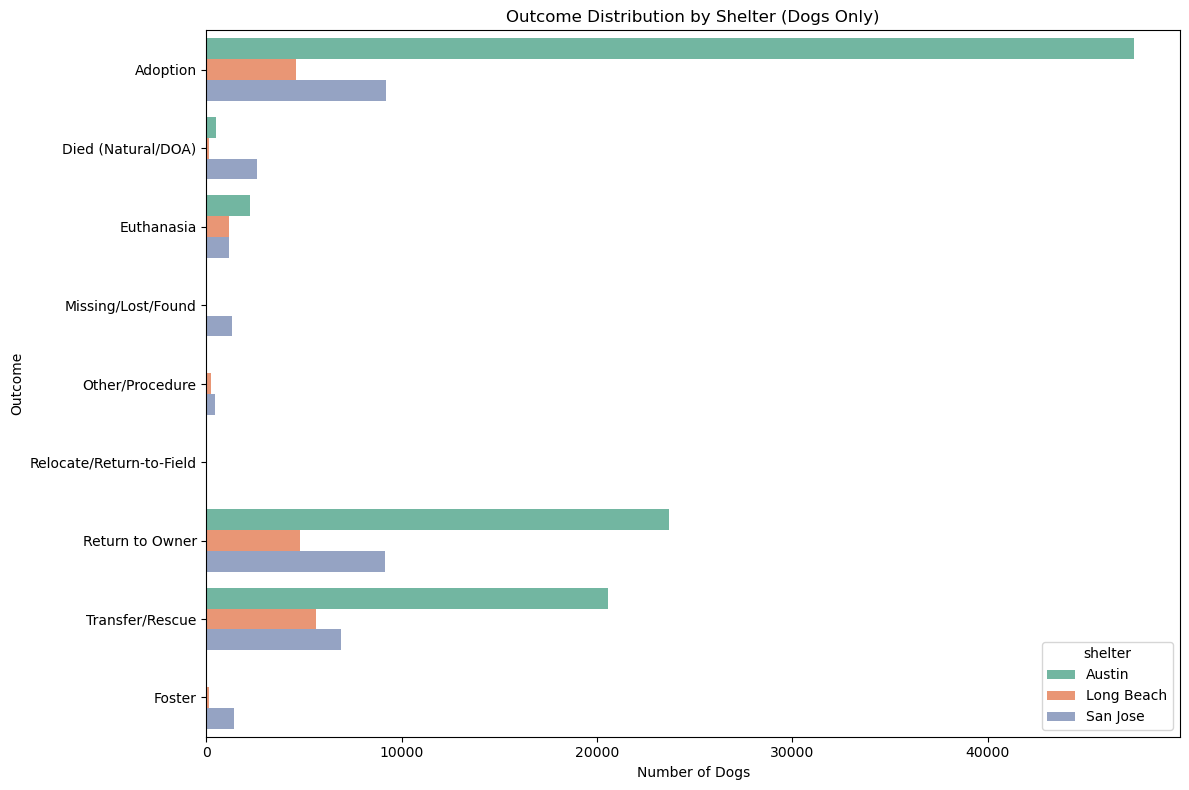

<Figure size 640x480 with 0 Axes>

In [7]:
# Compute distribution
outcome_by_shelter = (
    dogs.groupby(["shelter", "outcome_canonical"])
        .size()
        .reset_index(name="count")
)

plt.figure(figsize=(12,8))
sns.barplot(
    data=outcome_by_shelter,
    x="count",
    y="outcome_canonical",
    hue="shelter",
    palette="Set2"
)

plt.title("Outcome Distribution by Shelter (Dogs Only)")
plt.xlabel("Number of Dogs")
plt.ylabel("Outcome")
plt.tight_layout()
plt.show()

#Saving as Image
plt.savefig("outcomedistributionshelter.png", dpi=300)

/tmp/ipykernel_618/1763872339.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


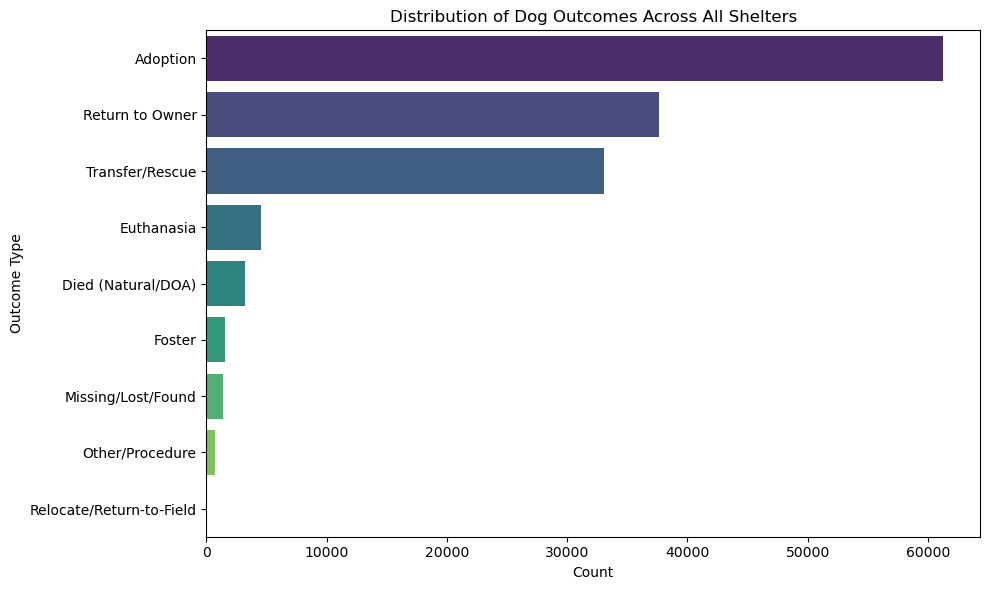

NameError: name 'fig' is not defined

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to dogs only (in case you haven't yet)
dogs = full_data[full_data["animal_type_canonical"] == "Dog"].copy()

plt.figure(figsize=(10,6))
sns.countplot(
    data=dogs,
    y="outcome_canonical",
    order=dogs["outcome_canonical"].value_counts().index,
    palette="viridis"
)
plt.title("Distribution of Dog Outcomes Across All Shelters")
plt.xlabel("Count")
plt.ylabel("Outcome Type")
plt.tight_layout()
plt.show()

#Saving as Image
fig.savefig("scatter.png", dpi=300)

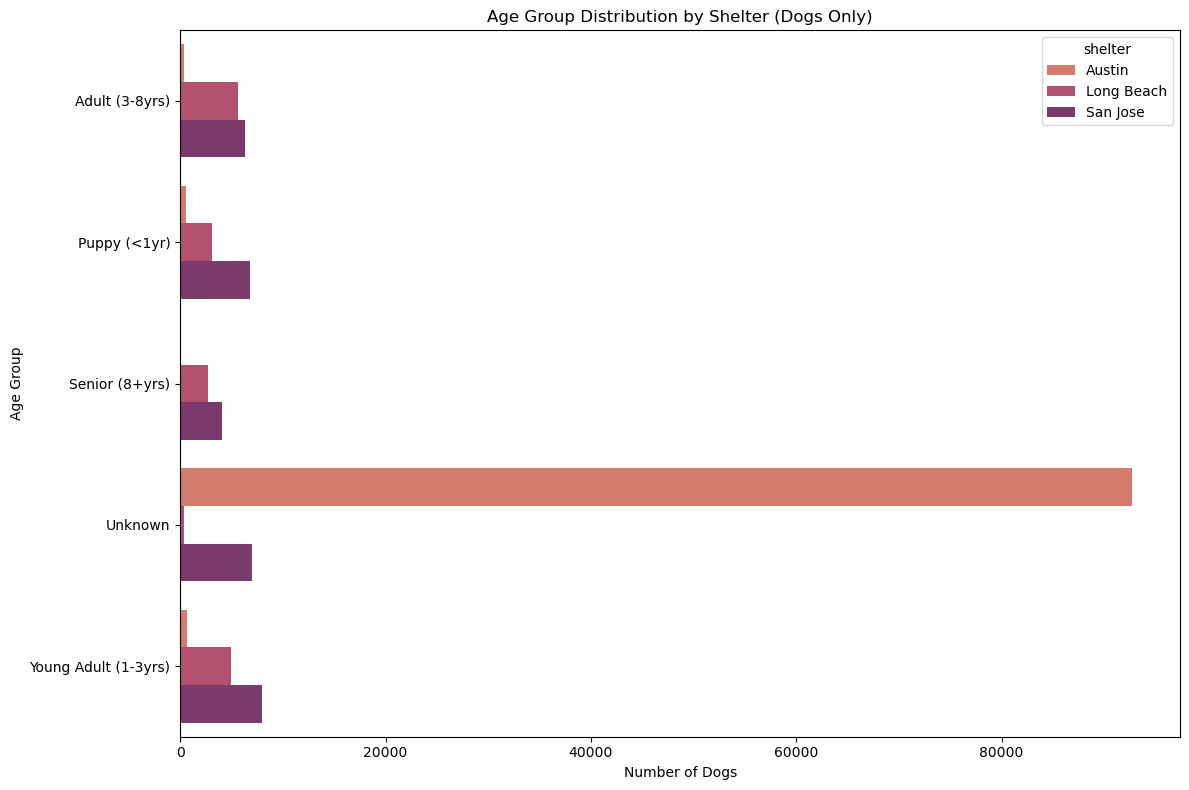

In [9]:
# Ensure age_group exists
def assign_age_group(age):
    if pd.isna(age):
        return "Unknown"
    elif age < 1:
        return "Puppy (<1yr)"
    elif age < 3:
        return "Young Adult (1-3yrs)"
    elif age < 8:
        return "Adult (3-8yrs)"
    else:
        return "Senior (8+yrs)"

dogs["age_group"] = dogs["age_years"].apply(assign_age_group)

age_dist = (
    dogs.groupby(["shelter", "age_group"])
        .size()
        .reset_index(name="count")
)

plt.figure(figsize=(12,8))
sns.barplot(
    data=age_dist,
    x="count",
    y="age_group",
    hue="shelter",
    palette="flare"
)

plt.title("Age Group Distribution by Shelter (Dogs Only)")
plt.xlabel("Number of Dogs")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()


<h3>Third Visualisation: SEX VISUALISATIONS</h3>

In [10]:
# Count the number of dogs in each sex category
sex_counts = dogs["sex"].value_counts(dropna=False)

print(sex_counts)


sex
Neutered Male    54269
Spayed Female    45447
Intact Male      11442
Male             11346
Intact Female    10228
Female            8498
Unknown           2083
NaN                  1
Name: count, dtype: int64


/tmp/ipykernel_618/1186055196.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


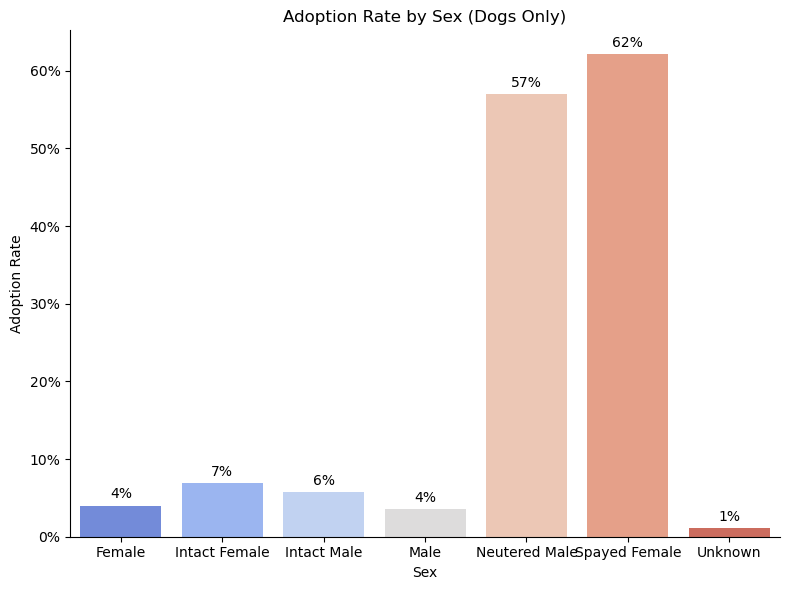

In [12]:

from matplotlib.ticker import FuncFormatter

# Ensure is_adopted exists
dogs["is_adopted"] = (dogs["outcome_canonical"] == "Adoption").astype(int)

# Adoption rate by sex
adopt_by_sex = (
    dogs.groupby("sex")["is_adopted"]
        .mean()
        .reset_index()
)

# Force correct category order if needed
adopt_by_sex["sex"] = adopt_by_sex["sex"].astype("category")
adopt_by_sex = adopt_by_sex.sort_values("sex")

fig, ax = plt.subplots(figsize=(8,6))

sns.barplot(
    data=adopt_by_sex,
    x="sex",             # <- genders on X axis
    y="is_adopted",
    palette="coolwarm",
    orient="v",          # <- forces vertical bars
    ax=ax
)

ax.set_title("Adoption Rate by Sex (Dogs Only)")
ax.set_xlabel("Sex")
ax.set_ylabel("Adoption Rate")

# Y-axis in percentages
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y*100:.0f}%"))

# Label bars with percentages
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v*100:.0f}%" for v in container.datavalues],
        padding=3
    )

sns.despine()
plt.tight_layout()

fig.savefig("adoption_rate_by_sex.png", dpi=300, bbox_inches="tight")

plt.show()


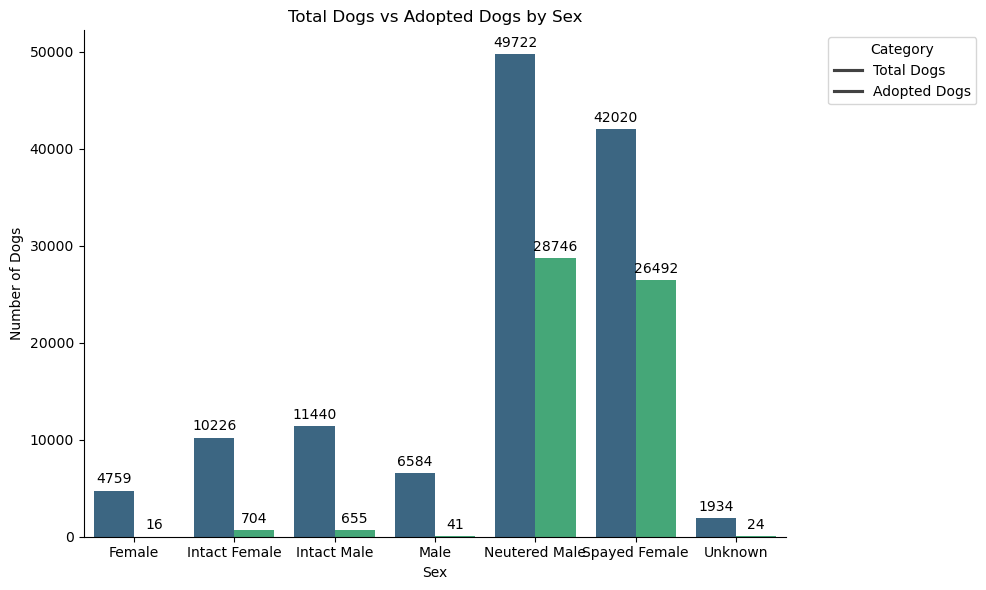

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Total count by sex ---
total_volume = (
    dogs.groupby("sex")
        .size()
        .reset_index(name="total_count")
)

# --- Adopted count by sex ---
adopted_volume = (
    dogs[dogs["outcome_canonical"] == "Adoption"]
        .groupby("sex")
        .size()
        .reset_index(name="adopt_count")
)

# Merge them together
sex_compare = total_volume.merge(adopted_volume, on="sex", how="left").fillna(0)

# Melt so seaborn can plot side-by-side bars
sex_compare_melted = sex_compare.melt(
    id_vars="sex",
    value_vars=["total_count", "adopt_count"],
    var_name="category",
    value_name="count"
)

# ✅ Create fig, ax explicitly
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=sex_compare_melted,
    x="sex",
    y="count",
    hue="category",
    palette="viridis",
    ax=ax
)

ax.set_title("Total Dogs vs Adopted Dogs by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Number of Dogs")
ax.legend(
    title="Category",
    labels=["Total Dogs", "Adopted Dogs"],
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Add value labels on each bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

sns.despine()
fig.tight_layout()

# ✅ Save THIS figure
fig.savefig("adoption_count_by_sex.png", dpi=300, bbox_inches="tight")

plt.show()


In [35]:
dogs.columns.tolist()


['animal_id',
 'animal_type',
 'breed',
 'name',
 'jurisdiction',
 'crossing',
 'outcome_type',
 'outcome_subtype',
 'outcome_condition',
 'intake_type',
 'intake_subtype',
 'intake_condition',
 'sex',
 'primary_color',
 'secondary_color',
 'dob',
 'intake_date',
 'outcome_date',
 'shelter',
 'analysis_date',
 'outcome_canonical',
 'animal_type_canonical',
 'age_years',
 'age_group',
 'is_adopted']

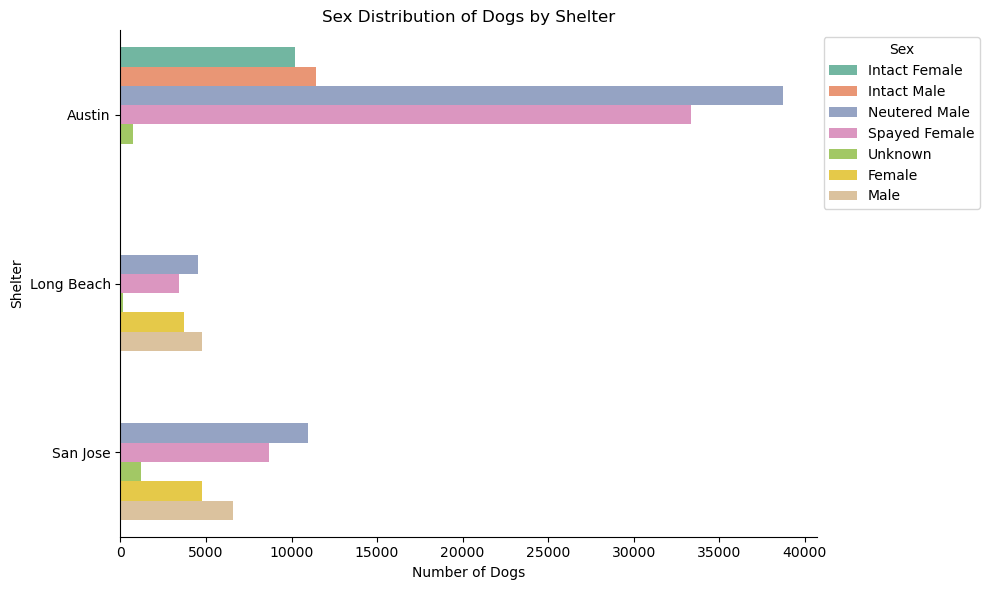

In [25]:
sex_shelter = (
    dogs.groupby(["shelter", "sex"])
        .size()
        .reset_index(name="count")
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=sex_shelter,
    x="count",
    y="shelter",
    hue="sex",
    palette="Set2"
)

plt.title("Sex Distribution of Dogs by Shelter")
plt.xlabel("Number of Dogs")
plt.ylabel("Shelter")
plt.legend(title="Sex", bbox_to_anchor=(1,1))
sns.despine()
plt.tight_layout()
plt.show()


<h3>Fourth Visualisation: DISTRIBUTIONS BY AGE</h3>

/tmp/ipykernel_618/3095977295.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_618/3095977295.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


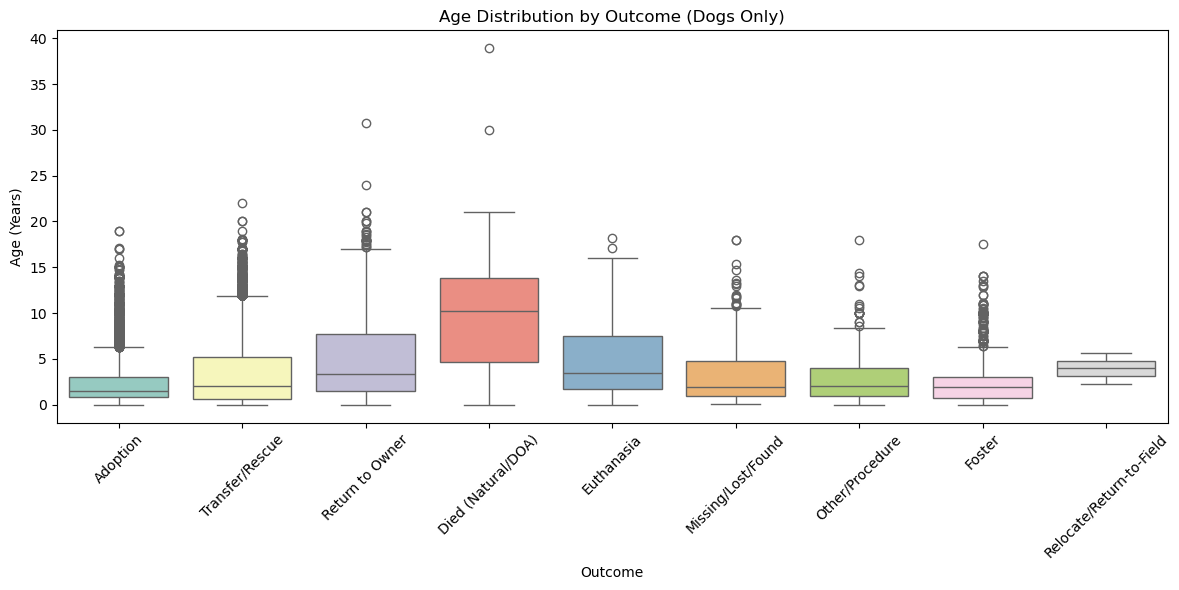

In [33]:
# Filter to dogs with valid ages
dogs_age = dogs[dogs["age_years"].notna()].copy()

# Create fig and ax properly
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=dogs_age,
    x="outcome_canonical",
    y="age_years",
    palette="Set3",
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title("Age Distribution by Outcome (Dogs Only)")
ax.set_xlabel("Outcome")
ax.set_ylabel("Age (Years)")

fig.tight_layout()

# Save image correctly
fig.savefig("boxplot_age.png", dpi=300, bbox_inches="tight")

plt.show()


/tmp/ipykernel_460/1182910504.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


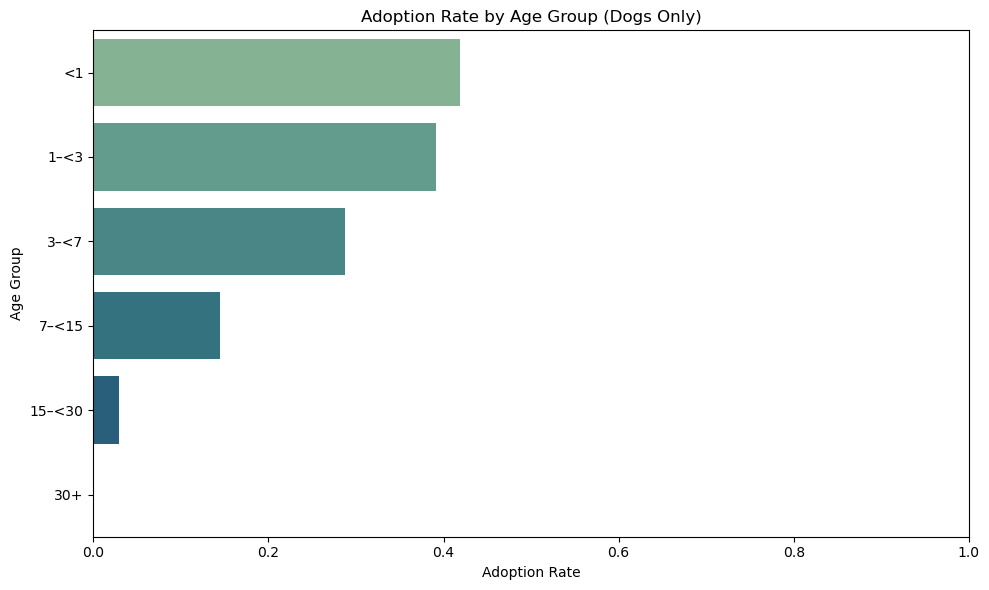

In [16]:
dogs["is_adopted"] = (dogs["outcome_canonical"] == "Adoption").astype(int)

adopt_by_age_group = (
    dogs.groupby("age_group")["is_adopted"]
        .mean()
        .reset_index()
        .sort_values("is_adopted", ascending=False)
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=adopt_by_age_group,
    x="is_adopted",
    y="age_group",
    palette="crest"
)

plt.title("Adoption Rate by Age Group (Dogs Only)")
plt.xlabel("Adoption Rate")
plt.ylabel("Age Group")
plt.xlim(0,1)
plt.tight_layout()
plt.show()


<h3>Fixing Breeds</h3>

In [17]:
import pandas as pd
import numpy as np
import re

# 1. Extract first part of mix and strip "Mix"
def extract_primary(breed_str):
    if pd.isna(breed_str):
        return "Unknown"
    s = str(breed_str).strip()
    # drop trailing "Mix"
    s = re.sub(r'\s+Mix$', '', s, flags=re.IGNORECASE)
    # take first part before "/"
    s = s.split("/")[0].strip()
    return s

dogs["breed_primary_raw"] = dogs["breed"].apply(extract_primary)

In [20]:
# normalize casing first
dogs["breed_primary_norm"] = dogs["breed_primary_raw"].str.strip()

# mapping for common abbreviations & variants
normalize_map = {
    "LABRADOR RETR": "Labrador Retriever",
    "LABRADOR RETRIE": "Labrador Retriever",
    "LABRADOR RETRIEVER": "Labrador Retriever",
    "LABRADOR RETRIE ": "Labrador Retriever",

    "CHIHUAHUA SH": "Chihuahua",
    "CHIHUAHUA SMOOT": "Chihuahua",
    "CHIHUAHUA LH": "Chihuahua Longhair",
    "CHIHUAHUA LONG": "Chihuahua Longhair",
    "CHIHUAHUA, OTHE": "Chihuahua",
    "CHIHUAHUA MIX;T": "Chihuahua",
    "CHIHUAHUA MIX;P": "Chihuahua",
    "CHIHUAHUA CHIHU": "Chihuahua",   # in case similar patterns exist

    "GERM SHEPHERD": "German Shepherd Dog",
    "GERM SHEPHERD ": "German Shepherd Dog",
    "GERM SHEPHERD DOG": "German Shepherd Dog",
    "GERM SHEPHERD DOG ": "German Shepherd Dog",
    "GERM SHEPHERD, AUSTR": "German Shepherd Dog",

    "GERM SH POINT": "German Shorthair Pointer",
    "GERM WH POINT": "German Wirehaired Pointer",

    "AUST CATTLE DOG": "Australian Cattle Dog",
    "AUST SHEPHERD": "Australian Shepherd",
    "AUST KELPIE": "Australian Kelpie",
    "AUST TERRIER": "Australian Terrier",

    "COCKER SPAN": "Cocker Spaniel",
    "ENG SPRNGR SPAN": "English Springer Spaniel",
    "ENG COCKER SPAN": "English Cocker Spaniel",
    "CAVALIER SPAN": "Cavalier King Charles Spaniel",

    "MIN PINSCHER": "Miniature Pinscher",
    "MIN PINSCH": "Miniature Pinscher",
    "SCHNAUZER MIN": "Miniature Schnauzer",
    "SCHNAUZER STAND": "Standard Schnauzer",
    "SCHNAUZER GIANT": "Schnauzer Giant",
    "POODLE MIN": "Miniature Poodle",
    "POODLE TOY": "Toy Poodle",
    "POODLE STND": "Standard Poodle",

    "YORKSHIRE TERR": "Yorkshire Terrier",
    "YORKSHIRE TERRI": "Yorkshire Terrier",

    "AM PIT BULL TER": "Pit Bull",
    "PIT BULL TERRIE": "Pit Bull",
    "PIT BULL": "Pit Bull",
    "PIT BULL ": "Pit Bull",

    "AUST KELPIE": "Australian Kelpie",
    "GERM SHEPHERD DOG": "German Shepherd Dog",

    "ST BERNARD SMTH": "St. Bernard Smooth Coat",
    "ST BERNARD RGH": "St. Bernard Rough Coat",
    "GREAT PYRENEES": "Great Pyrenees",
    "GREAT PYRENEESE": "Great Pyrenees",

    "BICHON FRISE": "Bichon Frise",
    "SC WHEAT TERR": "Soft Coated Wheaten Terrier",

    "BOXER, MIX": "Boxer",
    "POMERANIAN -MIX": "Pomeranian",
}

# apply mapping on UPPERCASE versions
dogs["breed_primary_norm"] = (
    dogs["breed_primary_norm"]
    .apply(lambda s: normalize_map.get(s.upper(), s))
)

In [21]:
normalize_map.update({
    "SIBERIAN HUSKY": "Siberian Husky",
    "MALTESE": "Maltese",
    "GERMAN SHEPHERD DOG": "German Shepherd",
    "SHIH TZU": "Shih Tzu",
    "FRENCH BULLDOG" : "French Bulldog",
    "BORDER COLLIE" : "Border Collie",
    "POMERANIAN" : "Pomeranian",
    "DACHSHUND" : "Dachshund",
    "PARSON RUSS TER" : "Parson Russell Terrier",
    "CAIRN TERRIER" : "Cairn Terrier",
    "PUG" : "Pug",
    "DOBERMAN PINSCH" : "Doberman Pinscher",
    "NORFOLK TERRIER" : "Norfolk Terrier",
    "BORDER TERRIER" : "Border Terrier",
    "BELG MALINOIS" : "Belgium Malinois",
})

dogs["breed_primary_norm"] = (
    dogs["breed_primary_norm"]
    .apply(lambda x: normalize_map.get(str(x).upper(), x))
)

In [22]:
breed_corrections = {
    # ---- Pit bull & bully-type normalization (Option A = all -> "Pit Bull") ----
    "Pit Bull": "Pit Bull",
    "PIT BULL": "Pit Bull",
    "Pitbull": "Pit Bull",
    "Pit Bull Terrier": "Pit Bull",
    "PIT BULL TERRIE": "Pit Bull",
    "AM PIT BULL TER": "Pit Bull",
    "AMERICAN PIT BU": "Pit Bull",
    "American Pit Bull Terrier": "Pit Bull",
    "American Pit Bull": "Pit Bull",

    # sometimes shelter codes where primary is clearly Pit Bull
    "AM PIT BULL TERRIER": "Pit Bull",
    "AMERICAN PIT BULL TERRIER": "Pit Bull",

    # ---- Chihuahua variants ----
    "CHIHUAHUA SH": "Chihuahua Shorthair",
    "Chihuahua Sh": "Chihuahua Shorthair",
    "CHIHUAHUA SMOOT": "Chihuahua Shorthair",
    "CHIHUAHUA LONG": "Chihuahua Longhair",
    "Chihuahua LH": "Chihuahua Longhair",
    "CHIHUAHUA LH": "Chihuahua Longhair",
    "CHIHUAHUA, OTHE": "Chihuahua",
    "CHIHUAHUA MIX;T": "Chihuahua",
    "CHIHUAHUA MIX;P": "Chihuahua",
    "DACHSHUND CHIHU": "Dachshund",  # take first breed
    "Chihuahua Shorthair": "Chihuahua Shorthair",
    "Chihuahua Longhair": "Chihuahua Longhair",

    # ---- Lab / shepherd / common big breeds ----
    "LABRADOR RETR": "Labrador Retriever",
    "LABRADOR RETRIE": "Labrador Retriever",
    "Labrador Retr": "Labrador Retriever",
    "Labrador Retr.": "Labrador Retriever",

    "GERM SHEPHERD": "German Shepherd",
    "SHEPHERD DOG, G": "German Shepherd Dog",
    "SHEPHERD, AUSTR": "Australian Shepherd",
    "AUST SHEPHERD": "Australian Shepherd",
    "AUST CATTLE DOG": "Australian Cattle Dog",
    "AUST KELPIE": "Australian Kelpie",
    "AUST TERRIER": "Australian Terrier",

    'Golden Retr': 'Golden Retriever',
    'GOLDEN RETR': 'Golden Retriever',

    # ---- Dachshund variants ----
    "DACHSHUND LH": "Dachshund Longhair",
    "DACHSHUND WH": "Dachshund Wirehair",
    "Dachshund Stan": "Dachshund",
    "DACHSHUND STAN": "Dachshund",
    "DACHSHUND CHIHU": "Dachshund",  # first breed
    
    # ---- Poodle variants ----
    "POODLE MIN": "Miniature Poodle",
    "POODLE TOY": "Toy Poodle",
    "POODLE STND": "Standard Poodle",
    "Poodle Min": "Miniature Poodle",
    "Poodle Toy": "Toy Poodle",
    "Poodle Stnd": "Standard Poodle",

    # ---- Terrier & small-dog codes ----
    "PARSON RUSS TER": "Parson Russell Terrier",
    "JACK RUSS TERR": "Jack Russell Terrier",
    "YORKSHIRE TERR": "Yorkshire Terrier",
    "YORKSHIRE TERRI": "Yorkshire Terrier",
    "SCOT TERRIER": "Scottish Terrier",
    "BEDLINGTON TERR": "Bedlington Terrier",
    "LAKELAND TERR": "Lakeland Terrier",
    "SEALYHAM TERR": "Sealyham Terr",
    "PATERDALE TERR": "Patterdale Terr",
    "PATTERDALE TERR": "Patterdale Terr",
    "TERRIER": "Terrier",
    "MIX;TERRIER": "Terrier",
    "MIX;TERRIER MIX": "Terrier",

    # ---- Misc common purebreds (uppercase codes -> nice case) ----
    "BEAGLE": "Beagle",
    "BEAGLE, MIX": "Beagle",
    "BEAGLE MIX": "Beagle",
    "SHIBA INU": "Shiba Inu",
    "BULL TERRIER": "Bull Terrier",
    "BOXER": "Boxer",
    "BOXER, MIX": "Boxer",
    "RAT TERRIER": "Rat Terrier",
    "PAPILLON": "Papillon",
    "AMER BULLDOG": "American Bulldog",
    "DOBERMAN PINSCH": "Doberman Pinscher",
    "YORKSHIRE TERRIER": "Yorkshire Terrier",
    "YORKSHIRE TERRI": "Yorkshire Terrier",
    "SIBERIAN HUSKY": "Siberian Husky",
    "FOX TERR WIRE": "Wire Hair Fox Terrier",
    "SILKY TERRIER": "Silky Terrier",
    "LHASA APSO": "Lhasa Apso",
    "STAFFORDSHIRE": "Staffordshire",
    "BASSET HOUND": "Basset Hound",
    "PEKINGESE": "Pekingese",
    "ROTTWEILER": "Rottweiler",
    "HAVANESE": "Havanese",
    "BICHON FRISE": "Bichon Frise",
    "CHINESE SHARPEI": "Chinese Sharpei",
    "NORFOLK TERRIER": "Norfolk Terrier",
    "CAVALIER SPAN": "Cavalier King Charles Spaniel",
    "CAVALIER SPANIEL": "Cavalier King Charles Spaniel",
    "CAVALIER KING CHARLES SPAN": "Cavalier King Charles Spaniel",
    "ALASKAN HUSKY": "Alaskan Husky",
    "ALASK MALAMUTE": "Alaskan Malamute",
    "ENG BULLDOG": "English Bulldog",
    "BOSTON TERRIER": "Boston Terrier",
    "SCHNAUZER MIN": "Miniature Schnauzer",
    "SCHNAUZER STAND": "Standard Schnauzer",
    "SCHNAUZER GIANT": "Schnauzer Giant",
    "ENG COCKER SPAN": "English Cocker Spaniel",
    "ENG SPRNGR SPAN": "English Springer Spaniel",
    "ENG POINTER": "English Pointer",
    "ENG FOXHOUND": "English Foxhound",
    "ENG COONHOUND": "English Coonhound",
    "ENG SHEPHERD": "English Shepherd",

    # ---- “AUST …” and similar abbreviations ----
    "AUST KELPIE": "Australian Kelpie",
    "AUST TERRIER": "Australian Terrier",
    "QUEENSLAND HEEL": "Queensland Heeler",
    "WELSH CORGI PEM": "Pembroke Welsh Corgi",
    "WELSH CORGI CAR": "Cardigan Welsh Corgi",
    "CARDIGAN  WELSH": "Cardigan Welsh Corgi",

    # ---- Hound & sighthound stuff ----
    "REDBONE HOUND": "Redbone Hound",
    "REDBONE HOUND/": "Redbone Hound",
    "PLOTT HOUND": "Plott Hound",
    "PBGV": "Pbgv",
    "TR WALKER HOUND": "Treeing Walker Coonhound",
    "TENN TR BRINDLE": "Treeing Tennesse Brindle",
    "BLUETICK HOUND": "Bluetick Hound",
    "ENG COONHOUND": "English Coonhound",

    # ---- Working & guardian breeds ----
    "NEAPOLITAN MAST": "Neapolitan Mastiff",
    "SPANISH MASTIFF": "Spanish Mastiff",
    "MASTIFF": "Mastiff",
    "BULLMASTIFF": "Bullmastiff",
    "DOGUE DE BORDX": "Dogue De Bordeaux",
    "DOGUE DE BORDX ": "Dogue De Bordeaux",
    "DOGUE DE BORDX": "Dogue De Bordeaux",
    "AKBASH": "Akbash",
    "KUVASZ": "Kuvasz",
    "KANGAL": "Kangal",
    "GR SWISS MTN": "Greater Swiss Mountain Dog",
    "GR SWISS MTN DOG": "Greater Swiss Mountain Dog",
    "ST BERNARD SMTH": "St. Bernard Smooth Coat",
    "ST BERNARD RGH": "St. Bernard Rough Coat",
    "BERNESE MTN DOG": "Bernese Mountain Dog",
    "NEWFOUNDLAND": "Newfoundland",
    "LANDSEER": "Landseer",
    "OLD ENG BULLDOG": "Old English Bulldog",
    "OLDENG SHEEPDOG": "Old English Sheepdog",
    "AKITA INU": "Akita",

    # ---- Misc less-common breeds & codes ----
    "PORT WATER DOG": "Port Water Dog",
    "CHESA BAY RETR": "Chesa Bay Retr",
    "Chesa Bay Retr": "Chesa Bay Retr",
    "NS DUCK TOLLING": "Nova Scotia Duck Tolling Retriever",
    "NS DUCK TOLLING RETR": "Nova Scotia Duck Tolling Retriever",
    "GORDON SETTER": "Gordon Setter",
    "BELG TERVUREN": "Belgian Tervuren",
    "Belgium Malinois": "Belgian Malinois",
    "BELG MALINOIS": "Belgian Malinois",
    "BELG SHEEPDOG": "Belgian Sheepdog",
    "PODENGO PEQUENO": "Podengo Pequeno",
    "KARELIAN BEAR": "Karelian Bear Dog",
    "SC WHEAT TERR": "Soft Coated Wheaten Terrier",
    "GR SWISS MTN": "Greater Swiss Mountain Dog",
    "SWED VALLHUND": "Swedish Vallhund",
    "NORW BUHUND": "Norwegian Buhund",
    "NS DUCK TOLLING": "Nova Scotia Duck Tolling Retriever",
    "COYOTE HYBRID": "Wolf Hybrid",
    "WELSH SPR SPAN": "Welsh Springer Spaniel",
    "SUSSEX SPAN": "Sussex Spaniel",
    "SPANISH MASTIFF": "Spanish Mastiff",
    "PUMI": "Pumi",
    "PLOTT HOUND": "Plott Hound",
    "TENN TR BRINDLE": "Treeing Tennesse Brindle",
    "POMERANIAN -MIX": "Pomeranian",
    "SHIH TZU -MIXED": "Shih Tzu",
    "AMER FOXHOUND": "American Foxhound",
    "AMER ESKIMO": "American Eskimo",
    "AMERICAN STAFF": "American Staffordshire Terrier",
    "AMERICAN COCKER": "American Cocker Spaniel",
    "AMERICAN PIT BU": "Pit Bull",

    # ---- Hairless, spitz, and other rarer codes ----
    "MEX HAIRLESS": "Mexican Hairless",
    "KOREAN JINDO": "Jindo",
    "JINDO": "Jindo",
    "CHINESE CRESTED": "Chinese Crested",
    "AKITA INU": "Akita",
    "SAMOYED": "Samoyed",
    "HOVAWART": "Hovawart",
    "PULI": "Puli",
    "PBGV": "Pbgv",

    # ---- Random text codes / placeholders / mix flags -> Unknown ----
    "Unknown": "Unknown",
    "UNKNOWN": "Unknown",
    "NaN": "Unknown",
    "0": "Unknown",
    "MIX": "Unknown",
    "MIXED BREED;TER": "Unknown",
    "MIXED BREED": "Unknown",
    "CHIHUAHUA MIX;P": "Unknown",
    "CHIHUAHUA MIX;T": "Unknown",
    "MALTI POO": "Unknown",  # you could map to Maltese/Poodle, but for primary "Unknown" is safest
    "COCKAPOO": "Unknown",
}
dogs["breed_primary_clean"] = (
    dogs["breed_primary_raw"]
      .str.strip()
      .map(breed_corrections)      # apply corrections
      .fillna(dogs["breed_primary_raw"])  # keep original if not in dict
)
dogs["breed_primary_norm"].unique()

array(['Black Mouth Cur', 'Chihuahua Shorthair', 'Shiba Inu',
       'Cocker Spaniel', 'American Pit Bull Terrier', 'Golden Retriever',
       'Miniature Pinscher', 'Pit Bull', 'Labrador Retriever', 'Havanese',
       'Rat Terrier', 'Pekingese', 'Basset Hound', 'Shih Tzu',
       'Lhasa Apso', 'Australian Cattle Dog', 'Miniature Schnauzer',
       'Dachshund', 'Pembroke Welsh Corgi', 'Carolina Dog', 'Rottweiler',
       'Border Collie', 'Cairn Terrier', 'Great Pyrenees',
       'Miniature Poodle', 'Redbone Hound', 'Pointer', 'Chinese Sharpei',
       'German Shepherd', 'Boxer', 'Chihuahua Longhair',
       'Australian Kelpie', 'Beagle', 'Harrier', 'Bruss Griffon',
       'Siberian Husky', 'English Pointer', 'Toy Poodle',
       'Australian Shepherd', 'Bull Terrier', 'Schnauzer Giant',
       'Yorkshire Terrier', 'Queensland Heeler', 'Pug', 'Plott Hound',
       'Jack Russell Terrier', 'Black', 'Cardigan Welsh Corgi',
       'Doberman Pinscher', 'Rhod Ridgeback', 'Jindo', 'Bichon Frise'

In [27]:
import pandas as pd
import numpy as np

# Map primary breeds to AKC-ish groups + Pit Bull group
akc_group_map = {
    # Pit bull–type
    "Pit Bull": "Terrier/Pit Bull",
    "American Pit Bull Terrier": "Terrier/Pit Bull",
    "American Staffordshire Terrier": "Terrier/Pit Bull",
    "Staffordshire": "Terrier/Pit Bull",

    # Sporting
    "Labrador Retriever": "Sporting",
    "Golden Retriever": "Sporting",
    "Cocker Spaniel": "Sporting",
    "English Springer Spaniel": "Sporting",
    "Chesa Bay Retr": "Sporting",
    "Weimaraner": "Sporting",
    "German Shorthair Pointer": "Sporting",
    "German Wirehaired Pointer": "Sporting",
    "English Setter": "Sporting",
    "Gordon Setter": "Sporting",
    "Brittany": "Sporting",
    "Pointer": "Sporting",
    "Vizsla": "Sporting",

    # Hound
    "Beagle": "Hound",
    "Basset Hound": "Hound",
    "Plott Hound": "Hound",
    "Bluetick Hound": "Hound",
    "Redbone Hound": "Hound",
    "Treeing Walker Coonhound": "Hound",
    "Treeing Tennesse Brindle": "Hound",
    "Greyhound": "Hound",
    "Whippet": "Hound",
    "Dachshund": "Hound",
    "Dachshund Longhair": "Hound",
    "Dachshund Wirehair": "Hound",
    "Harrier": "Hound",
    "Ibizan Hound": "Hound",
    "Pharaoh Hound": "Hound",
    "Saluki": "Hound",
    "BorzoI": "Hound",
    "Irish Wolfhound": "Hound",
    "Bloodhound": "Hound",

    # Working
    "Boxer": "Working",
    "Rottweiler": "Working",
    "Great Pyrenees": "Working",
    "Bernese Mountain Dog": "Working",
    "Newfoundland": "Working",
    "Great Dane": "Working",
    "Mastiff": "Working",
    "Bullmastiff": "Working",
    "Neapolitan Mastiff": "Working",
    "Doberman Pinscher": "Working",
    "Siberian Husky": "Working",
    "Alaskan Malamute": "Working",
    "Akita": "Working",
    "Anatol Shepherd": "Working",           # livestock guardian → treat as Working
    "Boerboel": "Working",
    "Cane Corso": "Working",
    "Samoyed": "Working",
    "St. Bernard Rough Coat": "Working",
    "St. Bernard Smooth Coat": "Working",
    "Greater Swiss Mountain Dog": "Working",

    # Herding
    "German Shepherd": "Herding",
    "German Shepherd Dog": "Herding",
    "Australian Shepherd": "Herding",
    "Australian Cattle Dog": "Herding",
    "Border Collie": "Herding",
    "Cardigan Welsh Corgi": "Herding",
    "Pembroke Welsh Corgi": "Herding",
    "Shetland Sheepdog": "Herding",
    "Australian Kelpie": "Herding",
    "Catahoula": "Herding",  # technically not AKC herding, but “herding-type” for analysis
    "Belgian Malinois": "Herding",
    "Belgian Tervuren": "Herding",
    "Belgian Sheepdog": "Herding",
    "Collie Rough": "Herding",
    "Collie Smooth": "Herding",

    # Terrier
    "Jack Russell Terrier": "Terrier",
    "Parson Russell Terrier": "Terrier",
    "Rat Terrier": "Terrier",
    "Cairn Terrier": "Terrier",
    "Norwich Terrier": "Terrier",
    "West Highland": "Terrier",
    "Scottish Terrier": "Terrier",
    "Miniature Schnauzer": "Terrier",
    "Schnauzer Giant": "Terrier",
    "Airedale Terrier": "Terrier",
    "Bull Terrier": "Terrier",
    "Bull Terrier Miniature": "Terrier",
    "Border Terrier": "Terrier",
    "Staffordshire Bull Terrier": "Terrier",  # if present
    "Soft Coated Wheaten Terrier": "Terrier",
    "Bedlington Terr": "Terrier",
    "Lakeland Terrier": "Terrier",
    "Sealyham Terr": "Terrier",
    "Irish Terrier": "Terrier",

    # Toy
    "Chihuahua": "Toy",
    "Chihuahua Shorthair": "Toy",
    "Chihuahua Longhair": "Toy",
    "Maltese": "Toy",
    "Yorkshire Terrier": "Toy",
    "Pomeranian": "Toy",
    "Papillon": "Toy",
    "Pekingese": "Toy",
    "Havanese": "Toy",
    "Miniature Pinscher": "Toy",
    "Toy Poodle": "Toy",
    "Cavalier King Charles Spaniel": "Toy",
    "Toy Fox Terrier": "Toy",
    "Shih Tzu": "Toy",
    "Bruss Griffon": "Toy",
    "Affenpinscher": "Toy",
    "Silky Terrier": "Toy",
    "Japanese Chin": "Toy",

    # Non-Sporting
    "French Bulldog": "Non-Sporting",
    "Miniature Poodle": "Non-Sporting",
    "Standard Poodle": "Non-Sporting",
    "Boston Terrier": "Non-Sporting",
    "Bulldog": "Non-Sporting",
    "Lhasa Apso": "Non-Sporting",
    "Chinese Sharpei": "Non-Sporting",
    "Dalmatian": "Non-Sporting",
    "Chow Chow": "Non-Sporting",
    "Keeshond": "Non-Sporting",
    "Shiba Inu": "Non-Sporting",
    "Coton De Tulear": "Non-Sporting",
    "Schipperke": "Non-Sporting",
    "Tibetan Terrier": "Non-Sporting",
    "Tibetan Spaniel": "Non-Sporting",
    "Bichon Frise": "Non-Sporting",

    # Foundation Stock / misc: you can shove into closest AKC-type
    "Black Mouth Cur": "Foundation/Working",
    "Carolina Dog": "Foundation/Working",
    "Blue Lacy": "Foundation/Working",
    "American Bulldog": "Foundation/Working",
    "Canaan Dog": "Foundation/Working",
    "Feist": "Foundation/Working",
    "Treeing Cur": "Foundation/Working",
}

# Create the group variable
dogs["akc_group"] = (
    dogs["breed_primary_clean"]
      .map(akc_group_map)
      .fillna("Other/Unknown")
)

# Optional: make it a categorical with a nice order
akc_order = [
    "Sporting", "Hound", "Working", "Herding",
    "Terrier", "Terrier/Pit Bull", "Toy",
    "Non-Sporting", "Foundation/Working", "Other/Unknown"
]
dogs["akc_group"] = pd.Categorical(dogs["akc_group"], categories=akc_order, ordered=False)


In [28]:
dogs["breed_akc_group"] = dogs["breed_primary_norm"].map(akc_group_map)
dogs["breed_akc_group"] = dogs["breed_akc_group"].fillna("Other/Unknown")


In [29]:
# Count breeds except Unknown
breed_counts = (
    dogs.loc[dogs["breed_primary_clean"] != "Unknown", "breed_primary_clean"]
        .value_counts()
)

# Actual top-20 breeds
top20_breeds = breed_counts.head(20).index.tolist()
print(top20_breeds)

# Create new variable
dogs["breed_top20"] = np.where(
    dogs["breed_primary_clean"].isin(top20_breeds),
    dogs["breed_primary_clean"],
    "Other breeds"
)

# Drop unknown
dogs = dogs[dogs["breed_primary_norm"] != "Unknown"]

# Identify top 20
top20 = (
    dogs["breed_primary_norm"]
    .value_counts()
    .head(20)
    .index
)

# Create top 20 + Other
dogs["breed_top20"] = dogs["breed_primary_norm"].apply(
    lambda b: b if b in top20 else "Other"
)

# Confirm counts
dogs["breed_top20"].value_counts()



['Pit Bull', 'Chihuahua Shorthair', 'Labrador Retriever', 'German Shepherd', 'Siberian Husky', 'Australian Cattle Dog', 'Miniature Poodle', 'Boxer', 'Dachshund', 'Border Collie', 'Chihuahua Longhair', 'Yorkshire Terrier', 'Great Pyrenees', 'Australian Shepherd', 'Beagle', 'Rat Terrier', 'Catahoula', 'Miniature Schnauzer', 'Rottweiler', 'Staffordshire']


breed_top20
Other                    36832
Pit Bull                 19115
Labrador Retriever       14714
Chihuahua Shorthair      10118
German Shepherd           9847
Chihuahua                 5779
Siberian Husky            4100
Australian Cattle Dog     3546
Dachshund                 2555
Miniature Poodle          2377
Border Collie             2250
Boxer                     1885
Chihuahua Longhair        1752
Yorkshire Terrier         1746
Maltese                   1679
Great Pyrenees            1666
Australian Shepherd       1509
Shih Tzu                  1380
Cairn Terrier             1331
Catahoula                 1260
Miniature Schnauzer       1245
Name: count, dtype: int64

<h3>Fifth Visualisation: Breed Level Adoption Rate</h3>

/tmp/ipykernel_618/2971638980.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


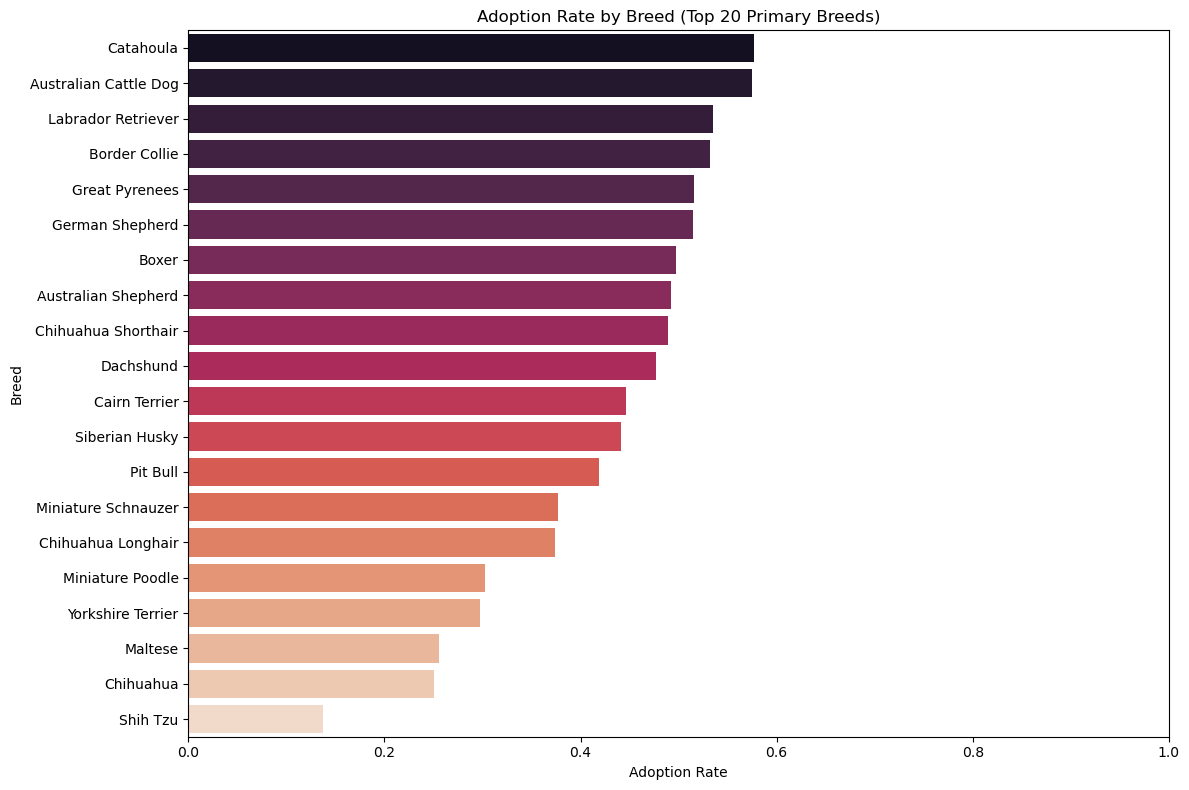

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Binary adoption variable
dogs["is_adopted"] = (dogs["outcome_canonical"] == "Adoption").astype(int)

# 2. Drop unknown primary breed (normalized)
dogs = dogs[dogs["breed_primary_norm"] != "Unknown"]

# 3. Identify top 20 most common breeds (normalized)
top20 = (
    dogs["breed_primary_norm"]
    .value_counts()
    .head(20)
    .index
)

# 4. Create "top 20 + Other" variable
dogs["breed_top20"] = dogs["breed_primary_norm"].apply(
    lambda b: b if b in top20 else "Other"
)

# 5. Keep only the actual top 20 for this plot (drop "Other")
dogs_top20 = dogs[dogs["breed_top20"] != "Other"]

# 6. Compute adoption rate by breed for the top 20
adopt_by_breed = (
    dogs_top20.groupby("breed_top20")["is_adopted"]
    .mean()
    .reset_index()
    .rename(columns={"breed_top20": "breed"})
    .sort_values("is_adopted", ascending=False)
)

# 7. Plot
fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=adopt_by_breed,
    x="is_adopted",
    y="breed",
    palette="rocket",
    ax=ax
)

ax.set_title("Adoption Rate by Breed (Top 20 Primary Breeds)")
ax.set_xlabel("Adoption Rate")
ax.set_ylabel("Breed")
ax.set_xlim(0, 1)

plt.tight_layout()

# 8. Save image (note: use a breed-related filename)
fig.savefig("adoption_rate_by_breed_top20.png", dpi=300, bbox_inches="tight")

plt.show()


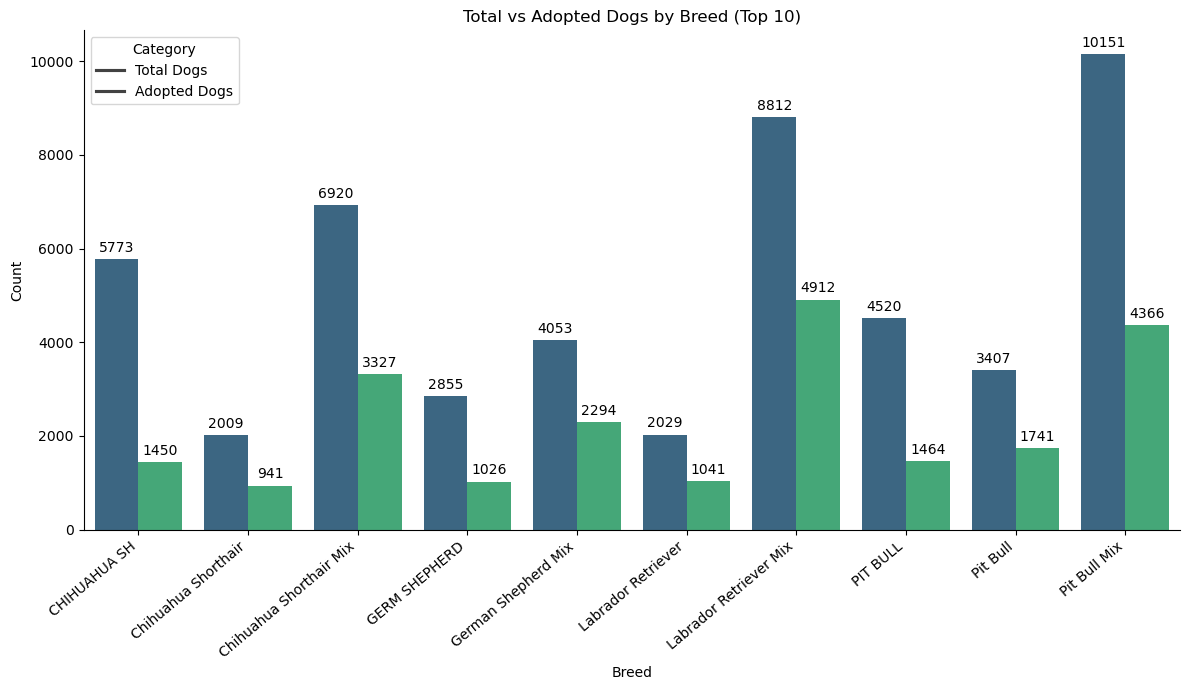

In [50]:
# Get top 10 breeds
top10_breeds = dogs["breed"].value_counts().head(10).index

dogs_breed10 = dogs[dogs["breed"].isin(top10_breeds)]

total_breed = (
    dogs_breed10.groupby("breed")
        .size()
        .reset_index(name="total_count")
)

adopt_breed = (
    dogs_breed10[dogs_breed10["outcome_canonical"] == "Adoption"]
        .groupby("breed")
        .size()
        .reset_index(name="adopt_count")
)

breed_compare = total_breed.merge(adopt_breed, on="breed", how="left").fillna(0)

breed_melt = breed_compare.melt(
    id_vars="breed",
    value_vars=["total_count", "adopt_count"],
    var_name="category",
    value_name="count"
)

plt.figure(figsize=(12,7))
sns.barplot(
    data=breed_melt,
    x="breed",
    y="count",
    hue="category",
    palette="viridis"
)

plt.title("Total vs Adopted Dogs by Breed (Top 10)")
plt.xlabel("Breed")
plt.ylabel("Count")
plt.xticks(rotation=40, ha="right")
plt.legend(title="Category", labels=["Total Dogs", "Adopted Dogs"])

ax = plt.gca()
for c in ax.containers:
    ax.bar_label(c, padding=3)

sns.despine()
plt.tight_layout()
plt.show()


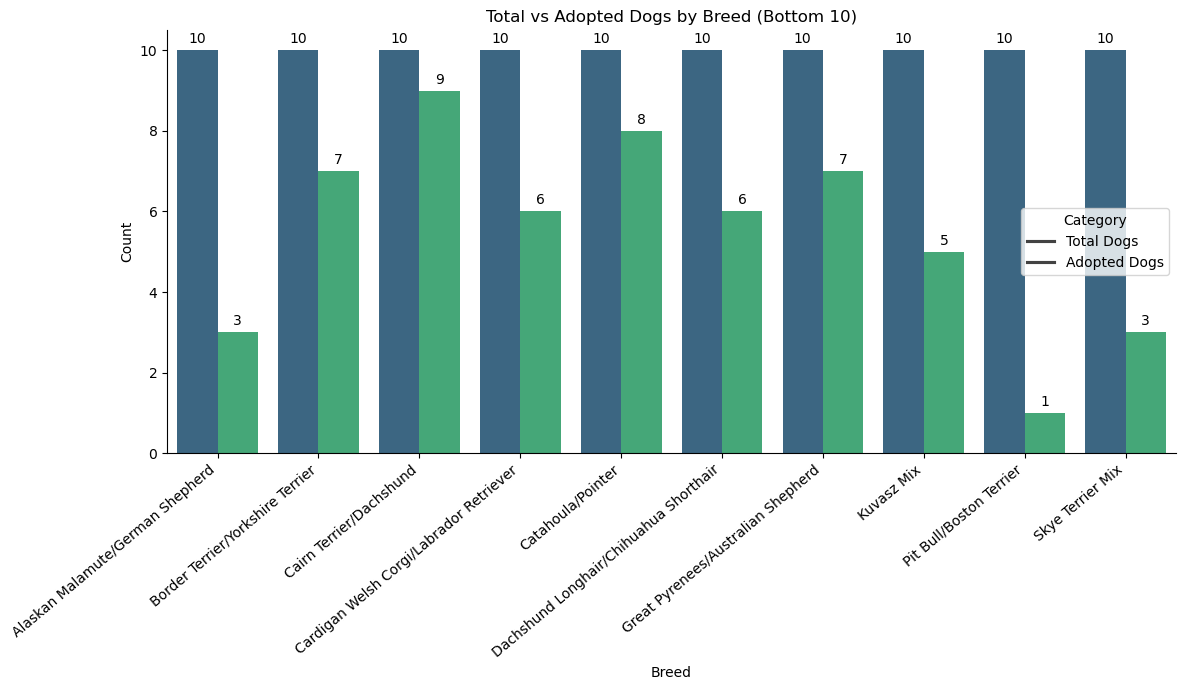

In [51]:
# Bottom 10 (min 10 observations to avoid noise)
breed_counts = dogs["breed"].value_counts()
bottom10_breeds = breed_counts[breed_counts >= 10].tail(10).index

dogs_rare = dogs[dogs["breed"].isin(bottom10_breeds)]

total_breed_r = (
    dogs_rare.groupby("breed")
        .size()
        .reset_index(name="total_count")
)

adopt_breed_r = (
    dogs_rare[dogs_rare["outcome_canonical"] == "Adoption"]
        .groupby("breed")
        .size()
        .reset_index(name="adopt_count")
)

breed_compare_r = total_breed_r.merge(adopt_breed_r, on="breed", how="left").fillna(0)

breed_melt_r = breed_compare_r.melt(
    id_vars="breed",
    value_vars=["total_count", "adopt_count"],
    var_name="category",
    value_name="count"
)

plt.figure(figsize=(12,7))
sns.barplot(
    data=breed_melt_r,
    x="breed",
    y="count",
    hue="category",
    palette="viridis"
)

plt.title("Total vs Adopted Dogs by Breed (Bottom 10)")
plt.xlabel("Breed")
plt.ylabel("Count")
plt.xticks(rotation=40, ha="right")
plt.legend(title="Category", labels=["Total Dogs", "Adopted Dogs"])

ax = plt.gca()
for c in ax.containers:
    ax.bar_label(c, padding=3)

sns.despine()
plt.tight_layout()
plt.show()


<h3>Seventh Visualisation: COLOR VISUALISATIONSr</h3>

/tmp/ipykernel_618/2377274149.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


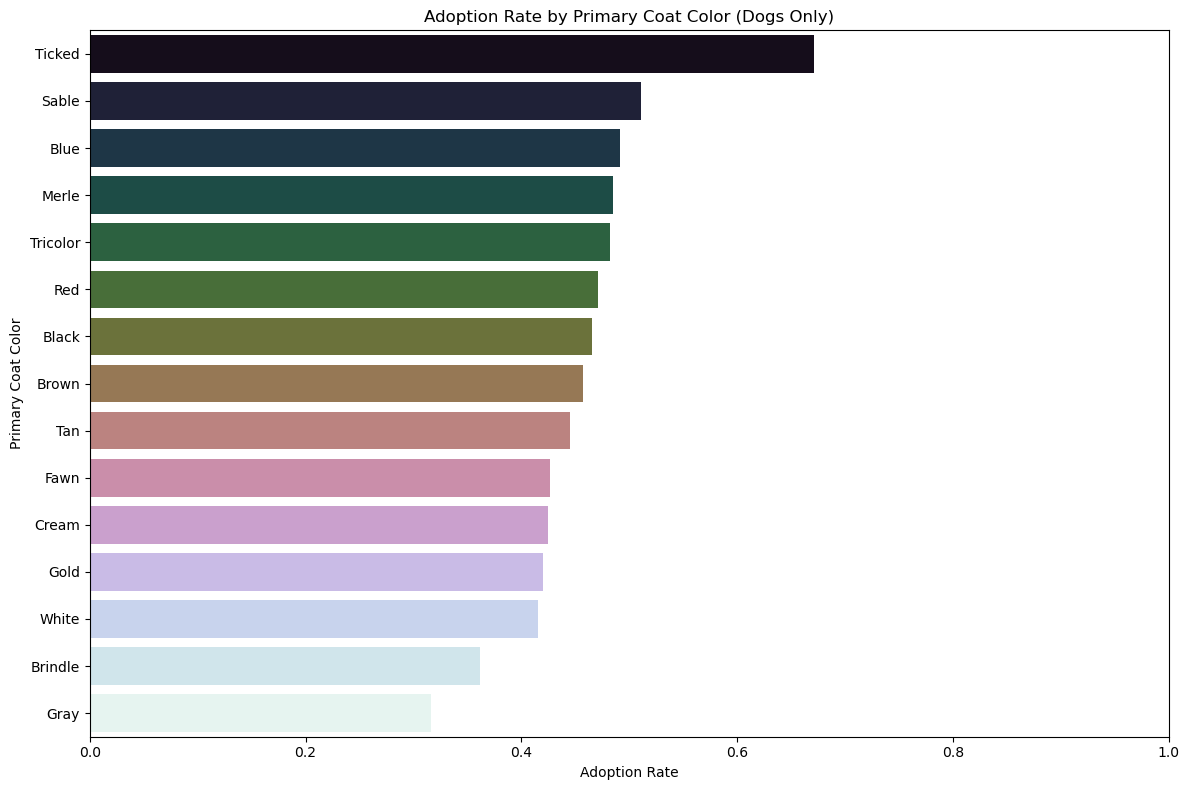

In [37]:
# Ensure binary adoption variable exists
dogs["is_adopted"] = (dogs["outcome_canonical"] == "Adoption").astype(int)

# Simplify rare colors
color_counts = dogs["primary_color_clean"].value_counts()
top_colors = color_counts[color_counts > 200].index  # colors with >200 dogs

dogs_color = dogs[dogs["primary_color_clean"].isin(top_colors)].copy()

# Compute adoption rate by color
adopt_by_color = (
    dogs_color.groupby("primary_color_clean")["is_adopted"]
        .mean()
        .reset_index()
        .sort_values("is_adopted", ascending=False)
)

# ---- FIX: create fig + ax properly ----
fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=adopt_by_color,
    y="primary_color_clean",
    x="is_adopted",
    palette="cubehelix",
    ax=ax
)

ax.set_title("Adoption Rate by Primary Coat Color (Dogs Only)")
ax.set_xlabel("Adoption Rate")
ax.set_ylabel("Primary Coat Color")
ax.set_xlim(0, 1)

fig.tight_layout()

# Save the image correctly
fig.savefig("adoption_rate_by_color.png", dpi=300, bbox_inches="tight")

plt.show()


/tmp/ipykernel_618/1864668879.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


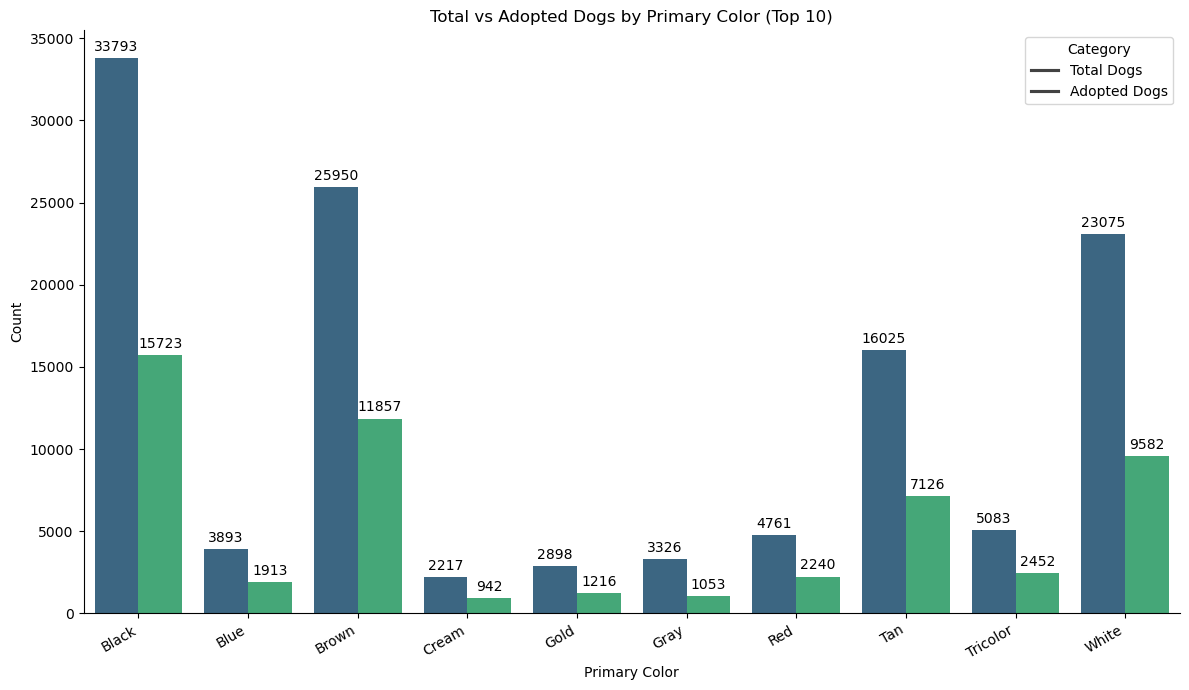

In [38]:
# Top 10 colors by total volume
top10_colors = (
    dogs["primary_color_clean"]
    .value_counts()
    .head(10)
    .index
)

dogs_color10 = dogs[dogs["primary_color_clean"].isin(top10_colors)]

# Total count
total_color = (
    dogs_color10.groupby("primary_color_clean")
        .size()
        .reset_index(name="total_count")
)

# Adopted count
adopt_color = (
    dogs_color10[dogs_color10["outcome_canonical"] == "Adoption"]
        .groupby("primary_color_clean")
        .size()
        .reset_index(name="adopt_count")
)

# Merge + reshape
color_compare = total_color.merge(adopt_color, on="primary_color_clean", how="left").fillna(0)

color_melt = color_compare.melt(
    id_vars="primary_color_clean",
    value_vars=["total_count", "adopt_count"],
    var_name="category",
    value_name="count"
)

# ---- FIXED: use fig + ax so saving works ----
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=color_melt,
    x="primary_color_clean",
    y="count",
    hue="category",
    palette="viridis",
    ax=ax
)

ax.set_title("Total vs Adopted Dogs by Primary Color (Top 10)")
ax.set_xlabel("Primary Color")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Category", labels=["Total Dogs", "Adopted Dogs"])

# Add labels
for c in ax.containers:
    ax.bar_label(c, padding=3)

sns.despine()
fig.tight_layout()

# ---- SAVE HERE ----
fig.savefig("adoption_counts_by_color.png", dpi=300, bbox_inches="tight")

plt.show()
